# ETA: Voxel Dataset Analysis
More thorough exploration of voxel tensors, distributions, and dataset-level summaries.

In [1]:
from pathlib import Path
import warnings
import numpy as np

# Find repo root (look for build_foundation_lcms.py)
def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for parent in [cur] + list(cur.parents):
        if (parent / "build_foundation_lcms.py").exists():
            return parent
    return cur

BASE_PATH = find_repo_root(Path.cwd())
DATA_VOXEL = BASE_PATH / "data" / "voxel"

print("BASE_PATH:", BASE_PATH)
print("VOXEL:", DATA_VOXEL)

try:
    import pandas as pd
except Exception as exc:
    pd = None
    warnings.warn(f"pandas not available: {exc}")

BASE_PATH: /home/simonp/FoundationMSMS
VOXEL: /home/simonp/FoundationMSMS/data/voxel


## 1. Build Voxel File Index
Scan voxel folders and create per-file and per-dataset tables.

In [2]:
MAX_VOXEL_FILES_PER_DATASET = None  # set an int to limit per dataset
rows = []
if not DATA_VOXEL.exists():
    print("Voxel base not found:", DATA_VOXEL)
else:
    for source_dir in sorted(DATA_VOXEL.iterdir()):
        if not source_dir.is_dir():
            continue
        source = source_dir.name
        for dataset_dir in sorted(source_dir.iterdir()):
            if not dataset_dir.is_dir():
                continue
            dataset = dataset_dir.name
            count = 0
            for p in dataset_dir.glob("*.npz"):
                rows.append({
                    "source": source,
                    "dataset": dataset,
                    "file": p.name,
                    "path": str(p),
                    "size_bytes": p.stat().st_size,
                })
                count += 1
                if MAX_VOXEL_FILES_PER_DATASET is not None and count >= MAX_VOXEL_FILES_PER_DATASET:
                    break

if pd is None:
    print("pandas is required for dataframe outputs.")
else:
    df_voxel_files = pd.DataFrame(rows)
    display(df_voxel_files.head())
    df_voxel_index = df_voxel_files.groupby(["source", "dataset"]).agg(
        file_count=("file", "count"),
        total_bytes=("size_bytes", "sum"),
    ).reset_index()
    display(df_voxel_index.sort_values(["source", "dataset"]).head(50))

,source,dataset,file,path,size_bytes
0,pride,PXD010595,01974c_BF1-TUM_missing_first_6_01_01-3xHCD-1h-...,/home/simonp/FoundationMSMS/data/voxel/pride/P...,19396816
1,pride,PXD010595,02208a_GD12-TUM_second_addon_48_01_01-DDA-1h-R...,/home/simonp/FoundationMSMS/data/voxel/pride/P...,189699874
2,pride,PXD010595,02080d_GB6-TUM_isoform_114_01_01-ETD-1h-R1.npz,/home/simonp/FoundationMSMS/data/voxel/pride/P...,4891935
3,pride,PXD010595,02208a_GA4-TUM_second_addon_4_01_01-DDA-1h-R1.npz,/home/simonp/FoundationMSMS/data/voxel/pride/P...,106902954
4,pride,PXD010595,02208a_GB6-TUM_second_addon_18_01_01-3xHCD-1h-...,/home/simonp/FoundationMSMS/data/voxel/pride/P...,16224221


,source,dataset,file_count,total_bytes
0,pride,PXD010595,12,953244527
1,pride,PXD012353,23,1228226790


## 2. Load Voxel Tensors
Load coords/vals from .npz and compute shape, min/max per dimension.

In [3]:
SOURCE = "pride"  # or "massive"
DATASET_ID = "PXD012353"  # set dataset to explore
MAX_FILES = 10

def load_voxel_npz(path: Path):
    npz = np.load(path)
    coords = npz["coords"]
    vals = npz["vals"]
    if coords.size == 0:
        shape = (0, 0, 0)
        dim_min = (0, 0, 0)
        dim_max = (0, 0, 0)
    else:
        dim_min = tuple(coords.min(axis=0).tolist())
        dim_max = tuple(coords.max(axis=0).tolist())
        shape = tuple((coords.max(axis=0) + 1).tolist())
    return coords, vals, shape, dim_min, dim_max

voxel_dir = DATA_VOXEL / SOURCE / DATASET_ID
if not voxel_dir.exists():
    print("Voxel dir not found:", voxel_dir)
else:
    voxel_files = sorted(voxel_dir.glob("*.npz"))
    tensors = []
    for p in voxel_files[:MAX_FILES]:
        coords, vals, shape, dim_min, dim_max = load_voxel_npz(p)
        tensors.append({
            "file": p.name,
            "shape": shape,
            "dim_min": dim_min,
            "dim_max": dim_max,
            "nnz": int(vals.size),
        })
    print("Loaded files:", len(tensors))
    if tensors:
        all_mins = np.array([t["dim_min"] for t in tensors])
        all_maxs = np.array([t["dim_max"] for t in tensors])
        global_min = tuple(all_mins.min(axis=0).tolist())
        global_max = tuple(all_maxs.max(axis=0).tolist())
        print("Global dim_min:", global_min, "dim_max:", global_max)
    if pd is not None and tensors:
        display(pd.DataFrame(tensors))

Loaded files: 10
Global dim_min: (0, 0, 0) dim_max: (1446, 1899, 8100)


,file,shape,dim_min,dim_max,nnz
0,20140103_Velos1_HRV_MV_DCmin1.npz,"(1445, 1900, 8099)","(0, 0, 2)","(1444, 1899, 8098)",6987607
1,20140103_Velos1_HRV_MV_DCmin2.npz,"(1447, 1900, 8096)","(0, 0, 69)","(1446, 1899, 8095)",9722974
2,20140103_Velos1_HRV_MV_DCmin3.npz,"(1309, 1900, 8099)","(0, 0, 435)","(1308, 1899, 8098)",4737652
3,20140103_Velos1_HRV_MV_DCmin4.npz,"(1447, 1900, 8101)","(0, 0, 121)","(1446, 1899, 8100)",2933855
4,20140103_Velos1_HRV_MV_DCmin5.npz,"(1447, 1900, 8099)","(0, 0, 0)","(1446, 1899, 8098)",9259705
5,20140103_Velos1_HRV_MV_DCmin6.npz,"(1420, 1900, 8099)","(0, 0, 1)","(1419, 1899, 8098)",11531528
6,20140103_Velos1_HRV_MV_DCplus1.npz,"(1445, 1900, 8097)","(0, 0, 2)","(1444, 1899, 8096)",7498799
7,20140103_Velos1_HRV_MV_DCplus2.npz,"(1168, 1900, 8100)","(0, 0, 436)","(1167, 1899, 8099)",3971994
8,20140103_Velos1_HRV_MV_DCplus3.npz,"(1445, 1900, 8101)","(0, 0, 0)","(1444, 1899, 8100)",13402885
9,20140103_Velos1_HRV_MV_DCplus4.npz,"(1445, 1900, 8100)","(0, 0, 272)","(1444, 1899, 8099)",7752029


## 3. Visualize Voxel Tensors
Plot 2D projections and a mid-RT slice from a selected voxel file.

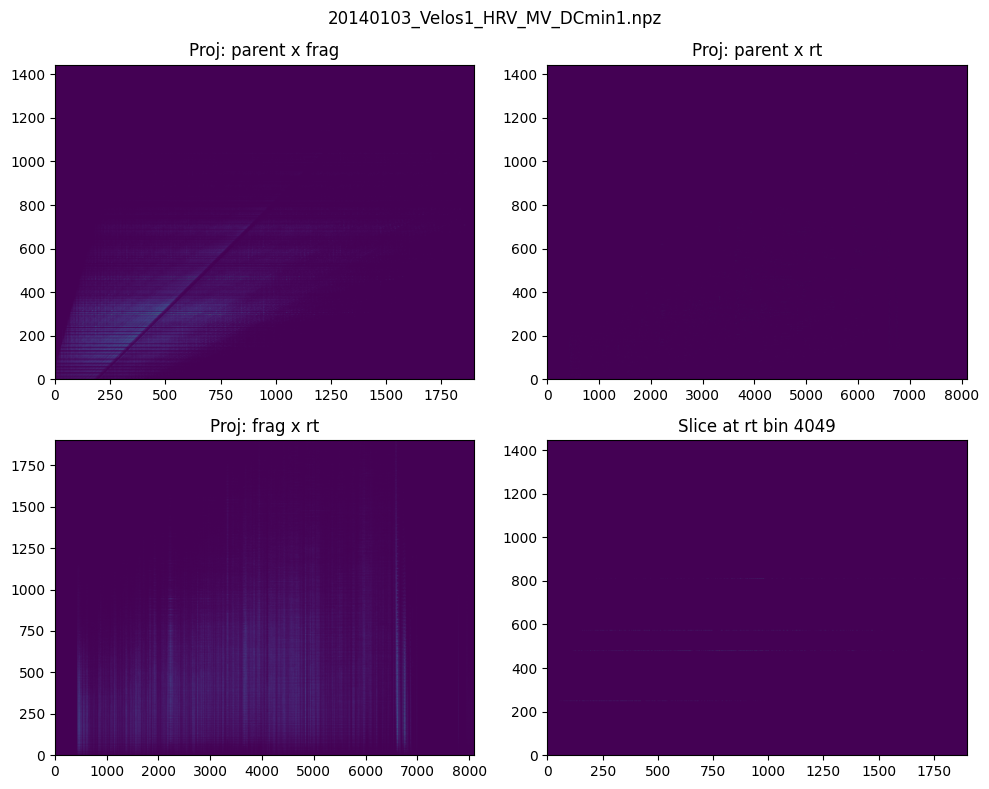

(6987607, 3)

In [4]:
# Select file index to visualize
FILE_INDEX = 0
DOWNSAMPLE = 1  # increase to shrink plots (e.g., 2, 4)
MAX_DIM = -1  # cap dimensions for visualization (<=0 means no cap)

if not voxel_dir.exists():
    print("Voxel dir not found:", voxel_dir)
else:
    voxel_files = sorted(voxel_dir.glob("*.npz"))
    if not voxel_files:
        print("No voxel files found in:", voxel_dir)
    else:
        p = voxel_files[min(FILE_INDEX, len(voxel_files) - 1)]
        npz = np.load(p)
        coords = npz["coords"]
        vals = npz["vals"]
        if coords.size == 0:
            print("Empty voxel file:", p.name)
        else:
            shape = tuple((coords.max(axis=0) + 1).tolist())
            # Optional downsample by integer factor
            if DOWNSAMPLE > 1:
                coords = (coords // DOWNSAMPLE).astype(coords.dtype)
                shape = tuple((coords.max(axis=0) + 1).tolist())
            # Cap dimensions for safe plotting (only if MAX_DIM > 0)
            if MAX_DIM > 0:
                shape = tuple(min(s, MAX_DIM) for s in shape)
            mask = (coords[:, 0] < shape[0]) & (coords[:, 1] < shape[1]) & (coords[:, 2] < shape[2])
            coords = coords[mask]
            vals = vals[mask]
            # 2D projections: sum over one axis
            proj_pf = np.zeros((shape[0], shape[1]), dtype=float)
            proj_pt = np.zeros((shape[0], shape[2]), dtype=float)
            proj_ft = np.zeros((shape[1], shape[2]), dtype=float)
            np.add.at(proj_pf, (coords[:, 0], coords[:, 1]), vals)
            np.add.at(proj_pt, (coords[:, 0], coords[:, 2]), vals)
            np.add.at(proj_ft, (coords[:, 1], coords[:, 2]), vals)
            # Mid-RT slice (tbin)
            t_mid = shape[2] // 2
            slice_pf = np.zeros((shape[0], shape[1]), dtype=float)
            in_slice = coords[:, 2] == t_mid
            if np.any(in_slice):
                np.add.at(slice_pf, (coords[in_slice, 0], coords[in_slice, 1]), vals[in_slice])
            try:
                import matplotlib.pyplot as plt
                fig, axes = plt.subplots(2, 2, figsize=(10, 8))
                axes[0, 0].imshow(proj_pf, aspect="auto", origin="lower")
                axes[0, 0].set_title("Proj: parent x frag")
                axes[0, 1].imshow(proj_pt, aspect="auto", origin="lower")
                axes[0, 1].set_title("Proj: parent x rt")
                axes[1, 0].imshow(proj_ft, aspect="auto", origin="lower")
                axes[1, 0].set_title("Proj: frag x rt")
                axes[1, 1].imshow(slice_pf, aspect="auto", origin="lower")
                axes[1, 1].set_title(f"Slice at rt bin {t_mid}")
                plt.suptitle(p.name)
                plt.tight_layout()
                plt.show()
            except Exception as exc:
                print("Plotting skipped:", exc)
coords.shape

## 4. Interactive Slices and 3D View
Interactive 2D slices by parent m/z bin and a 3D scatter view.

In [5]:
# Interactive 2D slice by parent m/z bin (pbin)
# Requires coords/vals loaded in the previous cell
if "coords" not in globals() or "vals" not in globals():
    print("Run the visualization cell first to load coords/vals.")
else:
    try:
        import matplotlib.pyplot as plt
        import ipywidgets as widgets
        from IPython.display import display
        # Only offer bins that actually have points to avoid empty slices
        pbin_vals = np.unique(coords[:, 0]).astype(int) if coords.size else np.array([], dtype=int)
        if pbin_vals.size == 0:
            print("No points available for interactive slices.")
        else:
            frag_max = int(coords[:, 1].max())
            rt_max = int(coords[:, 2].max())
            print("Slice image uses summed intensity per (frag, rt) bin.")
            print("Total points:", int(coords.shape[0]), "Total intensity sum:", float(vals.sum()))
            def show_slice(pbin):
                mask = coords[:, 0] == pbin
                count = int(mask.sum())
                if count == 0:
                    print("No points for pbin", pbin)
                    return
                img = np.zeros((frag_max + 1, rt_max + 1), dtype=float)
                np.add.at(img, (coords[mask, 1], coords[mask, 2]), vals[mask])
                nonzero = int(np.count_nonzero(img))
                img_min = float(img.min()) if img.size else 0.0
                img_max = float(img.max()) if img.size else 0.0
                print(
                    "pbin", pbin,
                    "points", count,
                    "slice intensity sum", float(vals[mask].sum()),
                    "nonzero bins", nonzero,
                    "img min/max", img_min, img_max,
                )
                plt.figure(figsize=(6, 4))
                if img_max > 0:
                    plt.imshow(img, aspect="auto", origin="lower", vmin=0, vmax=img_max)
                else:
                    plt.imshow(img, aspect="auto", origin="lower")
                plt.title(f"pbin={pbin} (frag x rt)")
                plt.tight_layout()
                plt.show()
                if img_max > 0 and nonzero > 0:
                    try:
                        from matplotlib.colors import LogNorm
                        plt.figure(figsize=(6, 4))
                        plt.imshow(img + 1e-9, aspect="auto", origin="lower", norm=LogNorm())
                        plt.title(f"pbin={pbin} (frag x rt) log scale")
                        plt.tight_layout()
                        plt.show()
                    except Exception as exc:
                        print("Log-scale plot skipped:", exc)
            slider = widgets.SelectionSlider(
                options=pbin_vals.tolist(),
                value=int(pbin_vals[0]),
                description="pbin",
                continuous_update=False,
            )
            display(widgets.interactive(show_slice, pbin=slider))
    except Exception as exc:
        print("Interactive slice skipped:", exc)

# 3D scatter view (interactive rotate via Plotly, downsample for speed)
if "coords" in globals() and coords.size:
    max_points = 20000
    if coords.shape[0] > max_points:
        idx = np.random.choice(coords.shape[0], size=max_points, replace=False)
        c = coords[idx]
        v = vals[idx]
    else:
        c = coords
        v = vals
    try:
        import plotly.graph_objects as go
        fig = go.Figure(
            data=go.Scatter3d(
                x=c[:, 0],
                y=c[:, 1],
                z=c[:, 2],
                mode="markers",
                marker=dict(
                    size=2,
                    color=v,
                    colorscale="Viridis",
                    opacity=0.7,
                ),
            )
        )
        fig.update_layout(
            scene=dict(
                xaxis_title="parent bin",
                yaxis_title="frag bin",
                zaxis_title="rt bin",
            ),
            margin=dict(l=0, r=0, b=0, t=30),
            title="3D voxel scatter (rotate with mouse)",
        )
        fig.show()
    except Exception as exc:
        print("Plotly 3D scatter skipped:", exc)
        try:
            import matplotlib.pyplot as plt
            from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
            fig = plt.figure(figsize=(7, 5))
            ax = fig.add_subplot(111, projection="3d")
            ax.scatter(c[:, 0], c[:, 1], c[:, 2], c=v, s=2, cmap="viridis")
            ax.set_xlabel("parent bin")
            ax.set_ylabel("frag bin")
            ax.set_zlabel("rt bin")
            plt.tight_layout()
            plt.show()
        except Exception as exc2:
            print("3D scatter skipped:", exc2)

Slice image uses summed intensity per (frag, rt) bin.
Total points: 6987607 Total intensity sum: 32855318.0


interactive(children=(SelectionSlider(continuous_update=False, description='pbin', options=(0, 1, 2, 3, 4, 5, …

In [6]:
# Plotly 3D scatter with click-to-read coordinates and inline slices
# Click a point to print its parent/frag/rt bins and intensity, plus three slices below.
if "coords" not in globals() or coords.size == 0:
    print("Run the visualization cell first to load coords/vals.")
else:
    TRACE_UID = "voxel-click-trace"
    last_click = None  # store last clicked coordinate triple
    try:
        import plotly.graph_objects as go
        import plotly.io as pio
        import ipywidgets as widgets
        from IPython.display import display
        import matplotlib.pyplot as plt

        try:
            if "vscode" in pio.renderers:
                pio.renderers.default = "vscode"
        except Exception:
            pass

        max_points = 20000
        if coords.shape[0] > max_points:
            idx = np.random.choice(coords.shape[0], size=max_points, replace=False)
            c = coords[idx]
            v = vals[idx]
        else:
            c = coords
            v = vals

        scatter = go.Scatter3d(
            x=c[:, 0],
            y=c[:, 1],
            z=c[:, 2],
            mode="markers",
            marker=dict(size=2, color=v, colorscale="Viridis", opacity=0.7),
        )
        scatter.uid = TRACE_UID

        fig = go.FigureWidget()
        fig.add_trace(scatter)
        fig.data[0].uid = TRACE_UID

        out_info = widgets.Output()
        out_slices = widgets.Output()

        def build_img(mask, axis0, axis1):
            if not np.any(mask):
                return None
            max0 = int(coords[mask, axis0].max())
            max1 = int(coords[mask, axis1].max())
            img = np.zeros((max0 + 1, max1 + 1), dtype=float)
            np.add.at(img, (coords[mask, axis0], coords[mask, axis1]), vals[mask])
            return img

        def handle_click(trace, points, selector):
            global last_click
            if not points.point_inds:
                return
            idx = points.point_inds[0]
            x, y, z = c[idx]
            intensity = float(v[idx])
            last_click = {"parent": int(x), "frag": int(y), "rt": int(z), "intensity": intensity}

            mask_p = coords[:, 0] == last_click["parent"]
            mask_f = coords[:, 1] == last_click["frag"]
            mask_t = coords[:, 2] == last_click["rt"]

            img_pf = build_img(mask_p, 1, 2)  # frag x rt @ parent
            img_pt = build_img(mask_f, 0, 2)  # parent x rt @ frag
            img_ft = build_img(mask_t, 0, 1)  # parent x frag @ rt

            with out_info:
                out_info.clear_output()
                print(
                    f"Clicked idx={idx} -> parent={last_click['parent']} frag={last_click['frag']} rt={last_click['rt']} intensity={intensity}"
                )
                print("Counts ->", "pbin slice", int(mask_p.sum()), "frag slice", int(mask_f.sum()), "rt slice", int(mask_t.sum()))
                print(
                    "Intensity ->",
                    "pbin sum", float(vals[mask_p].sum()),
                    "frag sum", float(vals[mask_f].sum()),
                    "rt sum", float(vals[mask_t].sum()),
                )

            with out_slices:
                out_slices.clear_output()
                fig_s, axes = plt.subplots(1, 3, figsize=(15, 4))
                titles = [
                    f"frag x rt @ parent={last_click['parent']}",
                    f"parent x rt @ frag={last_click['frag']}",
                    f"parent x frag @ rt={last_click['rt']}",
                ]
                for ax, img, title in zip(axes, [img_pf, img_pt, img_ft], titles):
                    if img is None:
                        ax.text(0.5, 0.5, "No points", ha="center", va="center")
                        ax.set_title(title)
                        ax.axis("off")
                        continue
                    vmax = img.max() if img.size else 0.0
                    ax.imshow(img, aspect="auto", origin="lower", vmin=0, vmax=vmax if vmax > 0 else None)
                    ax.set_title(title)
                plt.tight_layout()
                display(fig_s)
                plt.close(fig_s)

        fig.data[0].on_click(handle_click)

        fig.update_layout(
            scene=dict(xaxis_title="parent bin", yaxis_title="frag bin", zaxis_title="rt bin"),
            margin=dict(l=0, r=0, b=0, t=30),
            title="3D voxel scatter (click to read coords)",
        )

        display(fig, out_info, out_slices)
    except Exception as exc:
        print("Plotly click-enabled scatter skipped:", exc)
        try:
            fig = go.Figure(data=[scatter])
            fig.update_layout(
                scene=dict(xaxis_title="parent bin", yaxis_title="frag bin", zaxis_title="rt bin"),
                margin=dict(l=0, r=0, b=0, t=30),
                title="3D voxel scatter (static fallback)",
            )
            fig.show()
        except Exception as exc2:
            print("Plotly fallback scatter skipped:", exc2)


FigureWidget({
    'data': [{'marker': {'color': {'bdata': ('pfCtQHgtVUAfSqBAEkBIQP7CM0CxoD' ... 'FAUemBQIaxw0Ci+4pAs5WvQCtgaUA='),
                                   'dtype': 'f4'},
                         'colorscale': [[0.0, '#440154'], [0.1111111111111111,
                                        '#482878'], [0.2222222222222222,
                                        '#3e4989'], [0.3333333333333333,
                                        '#31688e'], [0.4444444444444444,
                                        '#26828e'], [0.5555555555555556,
                                        '#1f9e89'], [0.6666666666666666,
                                        '#35b779'], [0.7777777777777778,
                                        '#6ece58'], [0.8888888888888888,
                                        '#b5de2b'], [1.0, '#fde725']],
                         'opacity': 0.7,
                         'size': 2},
              'mode': 'markers',
              'type': 'scatter3d',
          

Output()

Output()

In [7]:
# Plot slices for the last clicked point (frag×rt, parent×rt, parent×frag)
if "coords" not in globals() or "vals" not in globals() or coords.size == 0:
    print("Run the visualization cell first to load coords/vals.")
elif "last_click" not in globals() or last_click is None:
    print("Click a point in the 3D plot to populate last_click.")
else:
    import matplotlib.pyplot as plt

    pbin = last_click["parent"]
    frag_bin = last_click["frag"]
    rt_bin = last_click["rt"]

    def build_img(mask, axis0, axis1):
        if not np.any(mask):
            return None
        max0 = int(coords[mask, axis0].max())
        max1 = int(coords[mask, axis1].max())
        img = np.zeros((max0 + 1, max1 + 1), dtype=float)
        np.add.at(img, (coords[mask, axis0], coords[mask, axis1]), vals[mask])
        return img

    mask_p = coords[:, 0] == pbin
    mask_f = coords[:, 1] == frag_bin
    mask_t = coords[:, 2] == rt_bin

    img_pf = build_img(mask_p, 1, 2)  # frag x rt @ parent
    img_pt = build_img(mask_f, 0, 2)  # parent x rt @ frag
    img_ft = build_img(mask_t, 0, 1)  # parent x frag @ rt

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    titles = [
        f"frag x rt @ parent={pbin}",
        f"parent x rt @ frag={frag_bin}",
        f"parent x frag @ rt={rt_bin}",
    ]
    for ax, img, title in zip(axes, [img_pf, img_pt, img_ft], titles):
        if img is None:
            ax.text(0.5, 0.5, "No points", ha="center", va="center")
            ax.set_title(title)
            ax.axis("off")
            continue
        vmax = img.max() if img.size else 0.0
        ax.imshow(img, aspect="auto", origin="lower", vmin=0, vmax=vmax if vmax > 0 else None)
        ax.set_title(title)
    plt.tight_layout()
    plt.show()

    print(
        "Counts ->",
        "pbin slice", int(mask_p.sum()),
        "frag slice", int(mask_f.sum()),
        "rt slice", int(mask_t.sum()),
    )
    print(
        "Intensity ->",
        "pbin sum", float(vals[mask_p].sum()),
        "frag sum", float(vals[mask_f].sum()),
        "rt sum", float(vals[mask_t].sum()),
    )


Click a point in the 3D plot to populate last_click.


pbin 307 points 24217 slice intensity sum 115347.5390625 nonzero bins 24217 img min/max 0.0 19.11792755126953


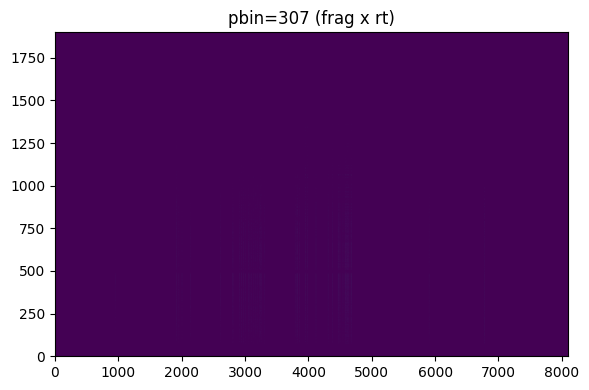

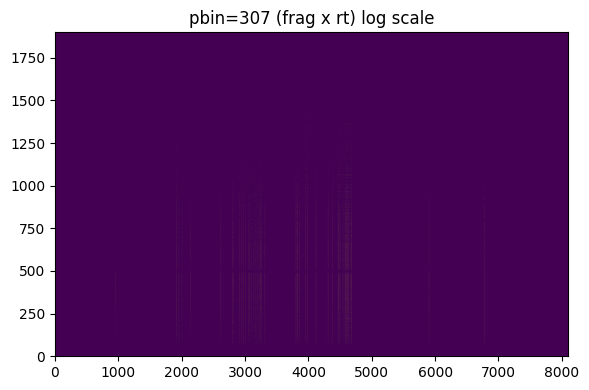

In [8]:
# Non-interactive slice for a chosen pbin (frag x rt)
PLOT_PBIN = 307  # parent bin for the slice
if "coords" not in globals() or "vals" not in globals():
    print("Run the visualization cell first to load coords/vals.")
else:
    mask = coords[:, 0] == PLOT_PBIN
    count = int(mask.sum())
    if count == 0:
        print("No points for pbin", PLOT_PBIN)
    else:
        frag_max = int(coords[:, 1].max())
        rt_max = int(coords[:, 2].max())
        img = np.zeros((frag_max + 1, rt_max + 1), dtype=float)
        np.add.at(img, (coords[mask, 1], coords[mask, 2]), vals[mask])
        nonzero = int(np.count_nonzero(img))
        img_min = float(img.min()) if img.size else 0.0
        img_max = float(img.max()) if img.size else 0.0
        print(
            "pbin", PLOT_PBIN,
            "points", count,
            "slice intensity sum", float(vals[mask].sum()),
            "nonzero bins", nonzero,
            "img min/max", img_min, img_max,
        )
        import matplotlib.pyplot as plt
        plt.figure(figsize=(6, 4))
        if img_max > 0:
            plt.imshow(img, aspect="auto", origin="lower", vmin=0, vmax=img_max)
        else:
            plt.imshow(img, aspect="auto", origin="lower")
        plt.title(f"pbin={PLOT_PBIN} (frag x rt)")
        plt.tight_layout()
        plt.show()
        if img_max > 0 and nonzero > 0:
            try:
                from matplotlib.colors import LogNorm
                plt.figure(figsize=(6, 4))
                plt.imshow(img + 1e-9, aspect="auto", origin="lower", norm=LogNorm())
                plt.title(f"pbin={PLOT_PBIN} (frag x rt) log scale")
                plt.tight_layout()
                plt.show()
            except Exception as exc:
                print("Log-scale plot skipped:", exc)

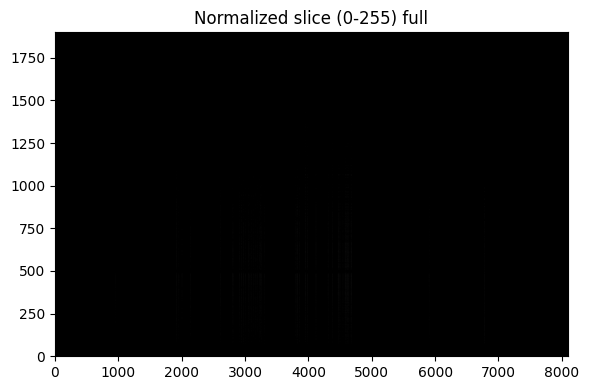

Crop nonzero bins: 615 Crop max: 173 Crop shape: (200, 200) Center: (409, 3790)


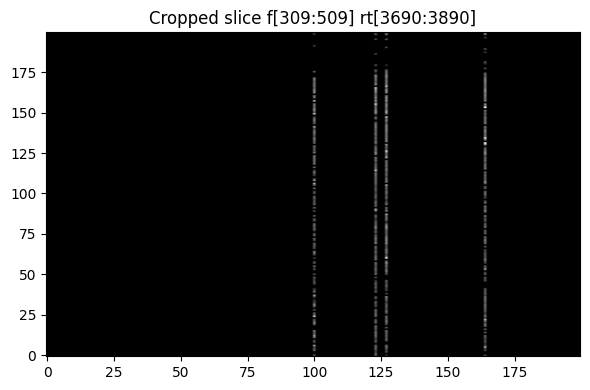

In [9]:
# Normalize image to 0-255 uint8 and plot (full + cropped view)
if "img" not in globals():
    print("Run the slice cell to create img.")
else:
    img_max = float(img.max()) if img.size else 0.0
    if img_max <= 0:
        img_norm = np.zeros_like(img, dtype=np.uint8)
    else:
        img_norm = np.clip(img / img_max * 255.0, 0, 255).astype(np.uint8)
    # Crop window centered on a known point (frag, rt)
    CENTER_FRAG = 409
    CENTER_RT = 3790
    HALF_SIZE = 100  # window radius in bins
    FRAG_RANGE = (CENTER_FRAG - HALF_SIZE, CENTER_FRAG + HALF_SIZE)
    RT_RANGE = (CENTER_RT - HALF_SIZE, CENTER_RT + HALF_SIZE)
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6, 4))
    plt.imshow(img_norm, aspect="auto", origin="lower", cmap="gray")
    plt.title("Normalized slice (0-255) full")
    plt.tight_layout()
    plt.show()
    if FRAG_RANGE is not None and RT_RANGE is not None:
        f0, f1 = FRAG_RANGE
        t0, t1 = RT_RANGE
        f0 = max(0, int(f0))
        t0 = max(0, int(t0))
        f1 = min(int(f1), img_norm.shape[0])
        t1 = min(int(t1), img_norm.shape[1])
        if f1 > f0 and t1 > t0:
            crop = img_norm[f0:f1, t0:t1]
            crop_nonzero = int(np.count_nonzero(crop))
            crop_max = int(crop.max()) if crop.size else 0
            print(
                "Crop nonzero bins:", crop_nonzero,
                "Crop max:", crop_max,
                "Crop shape:", crop.shape,
                "Center:", (CENTER_FRAG, CENTER_RT),
            )
            plt.figure(figsize=(6, 4))
            plt.imshow(crop, aspect="auto", origin="lower", cmap="gray")
            plt.title(f"Cropped slice f[{f0}:{f1}] rt[{t0}:{t1}]")
            plt.tight_layout()
            plt.show()
            if crop_nonzero == 0:
                print("Crop is empty (all zeros).")
        else:
            print("Invalid crop range:", FRAG_RANGE, RT_RANGE)
    img_norm.max(), img_norm.min(), img_norm.dtype

## 5. Slices At Chosen Coordinates
Interactively pick a parent bin, fragment bin, and RT bin to view three 2D slices (frag×rt, parent×rt, parent×frag). This pairs with the 3D scatter: read the coordinates off the hover text and set the sliders here.

In [10]:
# Quick voxel sanity check (run before the interactive plot)
from pathlib import Path
import numpy as np

print("voxel_dir:", voxel_dir)
files = sorted(Path(voxel_dir).glob("*.npz"))
print("npz files:", len(files))
if not files:
    print("No voxel files found. Check SOURCE/DATASET_ID and voxel_dir.")
else:
    p = files[min(FILE_INDEX, len(files) - 1)]
    npz = np.load(p)
    coords = npz["coords"]
    vals = npz["vals"]
    print("using file:", p.name)
    print("coords shape:", coords.shape, "vals size:", vals.size)
    if coords.size:
        print("dim min:", coords.min(axis=0), "dim max:", coords.max(axis=0))
        print("intensity sum:", float(vals.sum()))
    else:
        print("coords is empty in this file.")

voxel_dir: /home/simonp/FoundationMSMS/data/voxel/pride/PXD012353
npz files: 23
using file: 20140103_Velos1_HRV_MV_DCmin1.npz
coords shape: (6987607, 3) vals size: 6987607
dim min: [0 0 2] dim max: [1444 1899 8098]
intensity sum: 32855318.0


In [11]:
# Optional voxel binning to shrink dimensions (integer factors per axis)
BIN_FACTORS = (2, 20, 20)  # (parent_bin, frag_bin, rt_bin) factors
USE_BINNED_FOR_PLOTS = True  # if True, swap coords/vals to binned versions for downstream plots
if "coords" not in globals() or "vals" not in globals() or coords.size == 0:
    print("Run the load/visualization cell first to populate coords/vals.")
else:
    factors = np.array(BIN_FACTORS, dtype=int)
    if np.any(factors < 1):
        raise ValueError("All BIN_FACTORS must be >= 1")
    coords_raw = coords  # keep reference to original
    vals_raw = vals
    binned_coords = coords_raw // factors
    if binned_coords.size == 0:
        print("Coords array is empty after binning.")
    else:
        uniq, inv = np.unique(binned_coords, axis=0, return_inverse=True)
        binned_vals = np.zeros(uniq.shape[0], dtype=vals_raw.dtype)
        np.add.at(binned_vals, inv, vals_raw)
        shape_binned = tuple((uniq.max(axis=0) + 1).astype(int))
        print("Binned coords count:", uniq.shape[0], "shape:", shape_binned)
        print("Binned intensity sum:", float(binned_vals.sum()))
        if USE_BINNED_FOR_PLOTS:
            coords = uniq
            vals = binned_vals
            print("coords/vals swapped to binned versions for plotting.")
        else:
            print("Binned coords/vals available as uniq/binned_vals; original coords/vals kept.")

Binned coords count: 681453 shape: (np.int64(723), np.int64(95), np.int64(405))
Binned intensity sum: 32855318.0
coords/vals swapped to binned versions for plotting.


In [14]:
# Binned 3D scatter with click-to-slice (separate from raw coords)
# Computes a fresh binned set for visualization and shows slices on click.
BIN_FACTORS_VIS = (2, 2, 20)
if "coords" not in globals() or "vals" not in globals() or coords.size == 0:
    print("Run the load/visualization cell first to populate coords/vals.")
else:
    factors = np.array(BIN_FACTORS_VIS, dtype=int)
    if np.any(factors < 1):
        raise ValueError("All BIN_FACTORS_VIS must be >= 1")

    coords_binned = coords // factors
    if coords_binned.size == 0:
        print("Coords array is empty after binning.")
    else:
        uniq, inv = np.unique(coords_binned, axis=0, return_inverse=True)
        vals_binned = np.zeros(uniq.shape[0], dtype=vals.dtype)
        np.add.at(vals_binned, inv, vals)
        print("Binned coords count:", uniq.shape[0])
        print("Binned intensity sum:", float(vals_binned.sum()))

        try:
            import plotly.graph_objects as go
            import plotly.io as pio
            import ipywidgets as widgets
            import matplotlib.pyplot as plt
            from IPython.display import display

            if "vscode" in pio.renderers:
                pio.renderers.default = "vscode"
            elif "notebook_connected" in pio.renderers:
                pio.renderers.default = "notebook_connected"
            elif "notebook" in pio.renderers:
                pio.renderers.default = "notebook"

            max_points = 20000
            if uniq.shape[0] > max_points:
                idx = np.random.choice(uniq.shape[0], size=max_points, replace=False)
                c = uniq[idx]
                v = vals_binned[idx]
            else:
                c = uniq
                v = vals_binned

            scatter = go.Scatter3d(
                x=c[:, 0],
                y=c[:, 1],
                z=c[:, 2],
                mode="markers",
                marker=dict(size=2, color=v, colorscale="Viridis", opacity=0.7),
            )

            fig = go.FigureWidget([scatter]) if hasattr(go, "FigureWidget") else go.Figure(data=[scatter])
            out_info = widgets.Output()
            out_slices = widgets.Output()

            def build_img(mask, axis0, axis1):
                if not np.any(mask):
                    return None
                max0 = int(uniq[mask, axis0].max())
                max1 = int(uniq[mask, axis1].max())
                img = np.zeros((max0 + 1, max1 + 1), dtype=float)
                np.add.at(img, (uniq[mask, axis0], uniq[mask, axis1]), vals_binned[mask])
                return img

            def handle_click(trace, points, selector):
                if not points.point_inds:
                    return
                idx = points.point_inds[0]
                x, y, z = c[idx]
                intensity = float(v[idx])

                mask_p = uniq[:, 0] == x
                mask_f = uniq[:, 1] == y
                mask_t = uniq[:, 2] == z

                img_pf = build_img(mask_p, 1, 2)  # frag x rt @ parent
                img_pt = build_img(mask_f, 0, 2)  # parent x rt @ frag
                img_ft = build_img(mask_t, 0, 1)  # parent x frag @ rt

                with out_info:
                    out_info.clear_output()
                    print(f"Clicked -> parent={int(x)} frag={int(y)} rt={int(z)} intensity={intensity}")
                    print("Counts ->", "pbin slice", int(mask_p.sum()), "frag slice", int(mask_f.sum()), "rt slice", int(mask_t.sum()))
                    print(
                        "Intensity ->",
                        "pbin sum", float(vals_binned[mask_p].sum()),
                        "frag sum", float(vals_binned[mask_f].sum()),
                        "rt sum", float(vals_binned[mask_t].sum()),
                    )

                with out_slices:
                    out_slices.clear_output()
                    fig_s, axes = plt.subplots(1, 3, figsize=(15, 4))
                    titles = [
                        f"frag x rt @ parent={int(x)}",
                        f"parent x rt @ frag={int(y)}",
                        f"parent x frag @ rt={int(z)}",
                    ]
                    for ax, img, title in zip(axes, [img_pf, img_pt, img_ft], titles):
                        if img is None:
                            ax.text(0.5, 0.5, "No points", ha="center", va="center")
                            ax.set_title(title)
                            ax.axis("off")
                            continue
                        vmax = img.max() if img.size else 0.0
                        ax.imshow(img, aspect="auto", origin="lower", vmin=0, vmax=vmax if vmax > 0 else None)
                        ax.set_title(title)
                    plt.tight_layout()
                    display(fig_s)
                    plt.close(fig_s)

            if hasattr(fig, "data") and len(fig.data):
                try:
                    fig.data[0].on_click(handle_click)
                except Exception:
                    pass

            fig.update_layout(
                scene=dict(xaxis_title="parent bin (binned)", yaxis_title="frag bin (binned)", zaxis_title="rt bin (binned)"),
                margin=dict(l=0, r=0, b=0, t=30),
                title="Binned 3D voxel scatter (click to view slices)",
            )

            display(fig, out_info, out_slices)
        except Exception as exc:
            print("Binned click-enabled 3D scatter skipped:", exc)


Binned coords count: 85353
Binned intensity sum: 32855320.0


FigureWidget({
    'data': [{'marker': {'color': {'bdata': ('Ce4GRGgEREL8paFCu48jRB76YETAUx' ... 'FCz9JnQi9RWEEko45EdYBgQMVeWEM='),
                                   'dtype': 'f4'},
                         'colorscale': [[0.0, '#440154'], [0.1111111111111111,
                                        '#482878'], [0.2222222222222222,
                                        '#3e4989'], [0.3333333333333333,
                                        '#31688e'], [0.4444444444444444,
                                        '#26828e'], [0.5555555555555556,
                                        '#1f9e89'], [0.6666666666666666,
                                        '#35b779'], [0.7777777777777778,
                                        '#6ece58'], [0.8888888888888888,
                                        '#b5de2b'], [1.0, '#fde725']],
                         'opacity': 0.7,
                         'size': 2},
              'mode': 'markers',
              'type': 'scatter3d',
          

Output()

Output()

In [13]:
# 3D scatter with click-to-slice (no sliders)
# Click a point to print its coords/intensity and show three slices.
if "coords" not in globals() or "vals" not in globals() or coords.size == 0:
    print("Run the visualization cell first to load coords/vals.")
else:
    try:
        import plotly.graph_objects as go
        import plotly.io as pio
        import ipywidgets as widgets
        import matplotlib.pyplot as plt
        from IPython.display import display

        # Pick a renderer explicitly to avoid silent display issues
        if "vscode" in pio.renderers:
            pio.renderers.default = "vscode"
        elif "notebook_connected" in pio.renderers:
            pio.renderers.default = "notebook_connected"
        elif "notebook" in pio.renderers:
            pio.renderers.default = "notebook"

        # Patch Plotly FigureWidget to tolerate missing uid deltas (seen in some frontends)
        if not getattr(go.FigureWidget, "_patched_uid_handler", False):
            _orig_handler = go.FigureWidget._handler_js2py_traceDeltas

            def _safe_handler(self, change):
                try:
                    return _orig_handler(self, change)
                except KeyError:
                    # Ignore malformed deltas lacking uid instead of crashing
                    return None

            go.FigureWidget._handler_js2py_traceDeltas = _safe_handler
            go.FigureWidget._patched_uid_handler = True

        max_points = 20000
        if coords.shape[0] > max_points:
            idx = np.random.choice(coords.shape[0], size=max_points, replace=False)
            c = coords[idx]
            v = vals[idx]
        else:
            c = coords
            v = vals

        TRACE_UID = "voxel-click-trace"
        scatter = go.Scatter3d(
            x=c[:, 0],
            y=c[:, 1],
            z=c[:, 2],
            mode="markers",
            marker=dict(size=2, color=v, colorscale="Viridis", opacity=0.7),
            uid=TRACE_UID,
        )

        try:
            fig = go.FigureWidget([scatter])
            # Ensure uid is present on the stored trace for widget delta handling
            if fig.data:
                fig.data[0].uid = TRACE_UID
        except Exception:
            fig = None

        # Fallback: use static Figure if widget construction failed
        if fig is None:
            fig = go.Figure(data=[scatter])

        fig.update_layout(
            scene=dict(xaxis_title="parent bin", yaxis_title="frag bin", zaxis_title="rt bin"),
            margin=dict(l=0, r=0, b=0, t=30),
            title="3D voxel scatter (click to view slices)",
        )

        out_info = widgets.Output()
        out_slices = widgets.Output()

        def build_img(mask, axis0, axis1):
            if not np.any(mask):
                return None
            max0 = int(coords[mask, axis0].max())
            max1 = int(coords[mask, axis1].max())
            img = np.zeros((max0 + 1, max1 + 1), dtype=float)
            np.add.at(img, (coords[mask, axis0], coords[mask, axis1]), vals[mask])
            return img

        def handle_click(trace, points, selector):
            if not points.point_inds:
                return
            idx = points.point_inds[0]
            x, y, z = c[idx]
            intensity = float(v[idx])

            mask_p = coords[:, 0] == x
            mask_f = coords[:, 1] == y
            mask_t = coords[:, 2] == z

            img_pf = build_img(mask_p, 1, 2)  # frag x rt @ parent
            img_pt = build_img(mask_f, 0, 2)  # parent x rt @ frag
            img_ft = build_img(mask_t, 0, 1)  # parent x frag @ rt

            with out_info:
                out_info.clear_output()
                print(
                    f"Clicked -> parent={int(x)} frag={int(y)} rt={int(z)} intensity={intensity}"
                )
                print(
                    "Counts ->",
                    "pbin slice", int(mask_p.sum()),
                    "frag slice", int(mask_f.sum()),
                    "rt slice", int(mask_t.sum()),
                )
                print(
                    "Intensity ->",
                    "pbin sum", float(vals[mask_p].sum()),
                    "frag sum", float(vals[mask_f].sum()),
                    "rt sum", float(vals[mask_t].sum()),
                )

            with out_slices:
                out_slices.clear_output()
                fig_s, axes = plt.subplots(1, 3, figsize=(15, 4))
                titles = [
                    f"frag x rt @ parent={int(x)}",
                    f"parent x rt @ frag={int(y)}",
                    f"parent x frag @ rt={int(z)}",
                ]
                for ax, img, title in zip(axes, [img_pf, img_pt, img_ft], titles):
                    if img is None:
                        ax.text(0.5, 0.5, "No points", ha="center", va="center")
                        ax.set_title(title)
                        ax.axis("off")
                        continue
                    vmax = img.max() if img.size else 0.0
                    ax.imshow(img, aspect="auto", origin="lower", vmin=0, vmax=vmax if vmax > 0 else None)
                    ax.set_title(title)
                plt.tight_layout()
                display(fig_s)
                plt.close(fig_s)

        # Attach handler only if widget supports callbacks
        if hasattr(fig, "data") and len(fig.data):
            try:
                fig.data[0].on_click(handle_click)
            except Exception:
                pass

        # If we ended up with a static Figure (no widget), still show it
        display(fig, out_info, out_slices)
    except Exception as exc:
        print("Click-enabled 3D scatter skipped:", exc)


FigureWidget({
    'data': [{'marker': {'color': {'bdata': ('j7N2QjzvYELFQKFBQw9IQNSvzkFLAu' ... 'ZCzBpLQ3Elr0KYt4NCSGucQtn6N0I='),
                                   'dtype': 'f4'},
                         'colorscale': [[0.0, '#440154'], [0.1111111111111111,
                                        '#482878'], [0.2222222222222222,
                                        '#3e4989'], [0.3333333333333333,
                                        '#31688e'], [0.4444444444444444,
                                        '#26828e'], [0.5555555555555556,
                                        '#1f9e89'], [0.6666666666666666,
                                        '#35b779'], [0.7777777777777778,
                                        '#6ece58'], [0.8888888888888888,
                                        '#b5de2b'], [1.0, '#fde725']],
                         'opacity': 0.7,
                         'size': 2},
              'mode': 'markers',
              'type': 'scatter3d',
          

Output()

Output()